In [36]:
import pandas as pd
from fontTools.misc.arrayTools import offsetRect

df = pd.read_csv('brasileirao_2026.csv')

print(f"Jogos carregados: {len(df)}")
print(f"Rodadas: {df['rodada'].min()} a {df['rodada'].max()}")
df.head()

Jogos carregados: 77
Rodadas: 1 a 8


,data,rodada,status,time_casa,time_fora,gols_casa,gols_fora
0,2026-01-28,1,FINISHED,CA Mineiro,SE Palmeiras,2.0,2.0
1,2026-01-28,1,FINISHED,Coritiba FBC,RB Bragantino,0.0,1.0
2,2026-01-28,1,FINISHED,SC Internacional,CA Paranaense,0.0,1.0
3,2026-01-28,1,FINISHED,EC Vitória,Clube do Remo,2.0,0.0
4,2026-01-28,1,FINISHED,Fluminense FC,Grêmio FBPA,2.0,1.0


In [37]:
 #Primeiro bloco: Tabela de Desempenho Geral

#Métricas para jogos em casa:
casa = df.groupby('time_casa').agg(
    jogos_casa=('time_casa', 'count'),
    vitorias_casa=('gols_casa', lambda x: ((x > df.loc[x.index, 'gols_fora'])).sum()),
    empates_casa=('gols_casa', lambda x: ((x == df.loc[x.index, 'gols_fora'])).sum()),
    derrotas_casa=('gols_casa', lambda x: ((x < df.loc[x.index, 'gols_fora'])).sum()),
    gols_marcados_casa=('gols_casa', 'sum'),
    gols_sofridos_casa=('gols_fora', 'sum'),
).reset_index().rename(columns={'time_casa': 'time'})

#Métricas para jogos fora:
fora = df.groupby('time_fora').agg(
    jogos_fora=('time_fora', 'count'),
    vitorias_fora=('gols_fora', lambda x: ((x > df.loc[x.index, 'gols_casa'])).sum()),
    empates_fora=('gols_fora', lambda x: ((x == df.loc[x.index, 'gols_casa'])).sum()),
    derrotas_fora=('gols_fora', lambda x: ((x < df.loc[x.index, 'gols_casa'])).sum()),
    gols_marcados_fora=('gols_fora', 'sum'),
    gols_sofridos_fora=('gols_casa', 'sum'),
).reset_index().rename(columns={'time_fora': 'time'})

tabela = pd.merge(casa, fora, on='time')

#Calculando totais:
tabela['jogos']           = tabela['jogos_casa'] + tabela ['jogos_fora']
tabela['vitorias']        = tabela['vitorias_casa'] + tabela['vitorias_fora']
tabela['empates']         = tabela['empates_casa'] + tabela['empates_fora']
tabela['derrotas']        = tabela['derrotas_casa'] + tabela['derrotas_fora']
tabela['pontos']          = tabela['vitorias'] * 3 + tabela['empates']
tabela['gols_marcados']   = tabela['gols_marcados_casa'] + tabela['gols_marcados_fora']
tabela['gols_sofridos']   = tabela['gols_sofridos_casa'] + tabela['gols_sofridos_fora']
tabela['saldo_gols']      = tabela['gols_marcados'] - tabela['gols_sofridos']
tabela['aproveitamento']  = (tabela['pontos'] / (tabela['jogos'] * 3) * 100).round(1)

tabela_final = tabela[[
    'time', 'jogos', 'pontos', 'vitorias', 'empates', 'derrotas',
    'gols_marcados', 'gols_sofridos', 'saldo_gols', 'aproveitamento'
]].sort_values(
    ['pontos', 'vitorias', 'saldo_gols', 'gols_marcados'],
    ascending=[False, False, False, False]
).reset_index(drop=True)

tabela_final.index += 1

print("\nTabela de Desempenho Geral\n")
tabela_final


Tabela de Desempenho Geral



,time,jogos,pontos,vitorias,empates,derrotas,gols_marcados,gols_sofridos,saldo_gols,aproveitamento
1,SE Palmeiras,8,19,6,1,1,17.0,8.0,9.0,79.2
2,CA Paranaense,8,16,5,1,2,14.0,8.0,6.0,66.7
3,São Paulo FC,8,16,5,1,2,10.0,5.0,5.0,66.7
4,Fluminense FC,8,16,5,1,2,13.0,9.0,4.0,66.7
5,CR Flamengo,7,14,4,2,1,13.0,5.0,8.0,66.7
6,EC Bahia,7,14,4,2,1,9.0,7.0,2.0,66.7
7,Coritiba FBC,8,13,4,1,3,9.0,8.0,1.0,54.2
8,Grêmio FBPA,8,11,3,2,3,13.0,12.0,1.0,45.8
9,CR Vasco da Gama,8,11,3,2,3,13.0,13.0,0.0,45.8
10,EC Vitória,7,10,3,1,3,8.0,10.0,-2.0,47.6


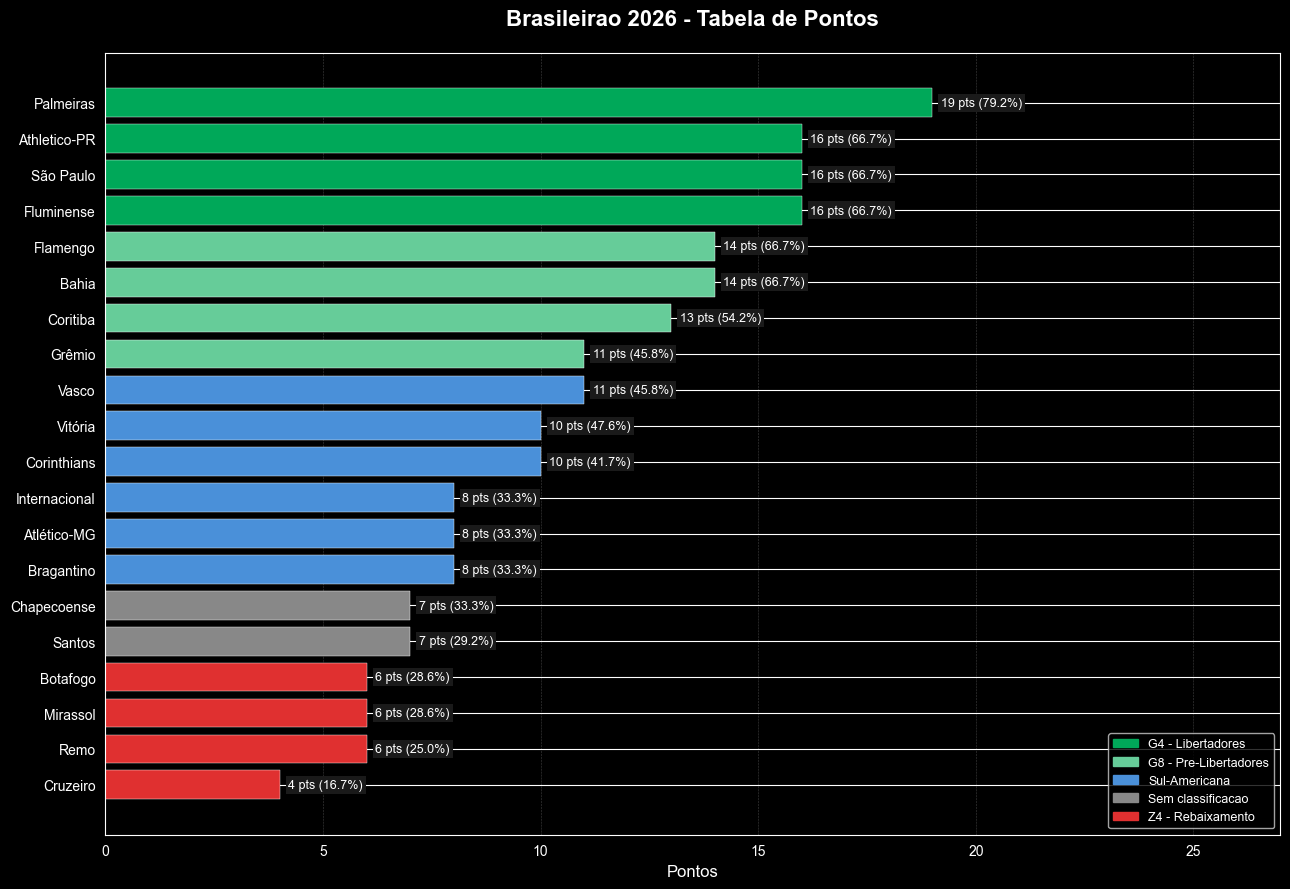

Grafico salvo!


In [38]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

#Mapeamento de nomes populares
nomes_populares = {
    'São Paulo FC': 'São Paulo',
    'SE Palmeiras': 'Palmeiras',
    'EC Bahia': 'Bahia',
    'Coritiba FBC': 'Coritiba',
    'Fluminense FC': 'Fluminense',
    'CR Flamengo': 'Flamengo',
    'CA Paranaense': 'Athletico-PR',
    'CA Mineiro': 'Atlético-MG',
    'SC Corinthians Paulista': 'Corinthians',
    'Grêmio FBPA': 'Grêmio',
    'RB Bragantino': 'Bragantino',
    'CR Vasco da Gama': 'Vasco',
    'EC Vitória': 'Vitória',
    'Santos FC': 'Santos',
    'Chapecoense AF': 'Chapecoense',
    'Mirassol FC': 'Mirassol',
    'SC Internacional': 'Internacional',
    'Botafogo FR': 'Botafogo',
    'Cruzeiro EC': 'Cruzeiro',
    'Clube do Remo': 'Remo',
}

#Aplicando nomes populares
tabela_final['time_popular'] = tabela_final['time'].map(nomes_populares).fillna(tabela_final['time'])

#Configuração do gráfico:
def cor_por_posicao(pos):
    if pos <= 4:
        return '#00A859'    #Verde — Libertadores
    elif pos <= 8:
        return '#66CC99'    #Verde claro — Pré-Libertadores
    elif pos <= 14:
        return '#4A90D9'    #Azul neutro — Sul-Americana
    elif pos <= 16:
        return '#888888'    #Cinza — Sem classificação
    else:
        return '#E03030'    #Vermelho — Rebaixamento

cores = [cor_por_posicao(i+1) for i in range(len(tabela_final))]

#Configuração de plot:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 9))

bars = ax.barh(
    tabela_final['time_popular'][::-1],
    tabela_final['pontos'][::-1],
    color=cores[::-1],
    edgecolor='white',
    linewidth=0.3
)

#Rótulos de barras:
for bar, pontos, aprov in zip(bars, tabela_final['pontos'][::-1], tabela_final['aproveitamento'][::-1]):
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f'{pontos} pts ({aprov}%)',
        va='center', ha='left', fontsize=9, color='white',
        bbox=dict(facecolor='#1a1a1a', edgecolor='none', pad=2)  # fundo escuro no texto
    )

ax.xaxis.grid(True, color='gray', linestyle='--', linewidth=0.4, alpha=0.5)
ax.set_axisbelow(True)

#Legendas:
patches = [
    mpatches.Patch(color='#00A859', label='G4 - Libertadores'),
    mpatches.Patch(color='#66CC99', label='G8 - Pre-Libertadores'),
    mpatches.Patch(color='#4A90D9', label='Sul-Americana'),
    mpatches.Patch(color='#888888', label='Sem classificacao'),
    mpatches.Patch(color='#E03030', label='Z4 - Rebaixamento'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)

# Título e label
ax.set_title('Brasileirao 2026 - Tabela de Pontos', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Pontos', fontsize=12)
ax.set_xlim(0, tabela_final['pontos'].max() + 8)

plt.tight_layout()
plt.subplots_adjust(left=0.15)
plt.savefig('tabela_brasileirao_2026.png', dpi=150, bbox_inches='tight')
plt.show()

print("Grafico salvo!")

In [39]:
#Salvando a tabela final com nomes populares
tabela_final.to_csv('tabela_desempenho_2026.csv', index=False)
print("Salvo")

Salvo


In [40]:
#Segundo bloco: Poder Ofensivo

#Medidas ofensivas
ofensivo = tabela_final[['time_popular', 'jogos', 'gols_marcados']].copy()
ofensivo['media_gols'] = (ofensivo['gols_marcados'] / ofensivo['jogos']).round(2)
ofensivo = ofensivo.sort_values('gols_marcados', ascending=False).reset_index(drop=True)
ofensivo.index += 1

print("BRASILEIRAO 2026 — Ranking Ofensivo")
print(ofensivo.to_string())

BRASILEIRAO 2026 — Ranking Ofensivo
     time_popular  jogos  gols_marcados  media_gols
1       Palmeiras      8           17.0        2.12
2    Athletico-PR      8           14.0        1.75
3      Fluminense      8           13.0        1.62
4        Flamengo      7           13.0        1.86
5           Vasco      8           13.0        1.62
6          Grêmio      8           13.0        1.62
7        Botafogo      7           11.0        1.57
8       São Paulo      8           10.0        1.25
9          Santos      8           10.0        1.25
10           Remo      8           10.0        1.25
11       Coritiba      8            9.0        1.12
12          Bahia      7            9.0        1.29
13    Chapecoense      7            9.0        1.29
14       Mirassol      7            8.0        1.14
15        Vitória      7            8.0        1.14
16    Atlético-MG      8            8.0        1.00
17       Cruzeiro      8            8.0        1.00
18    Corinthians      8    

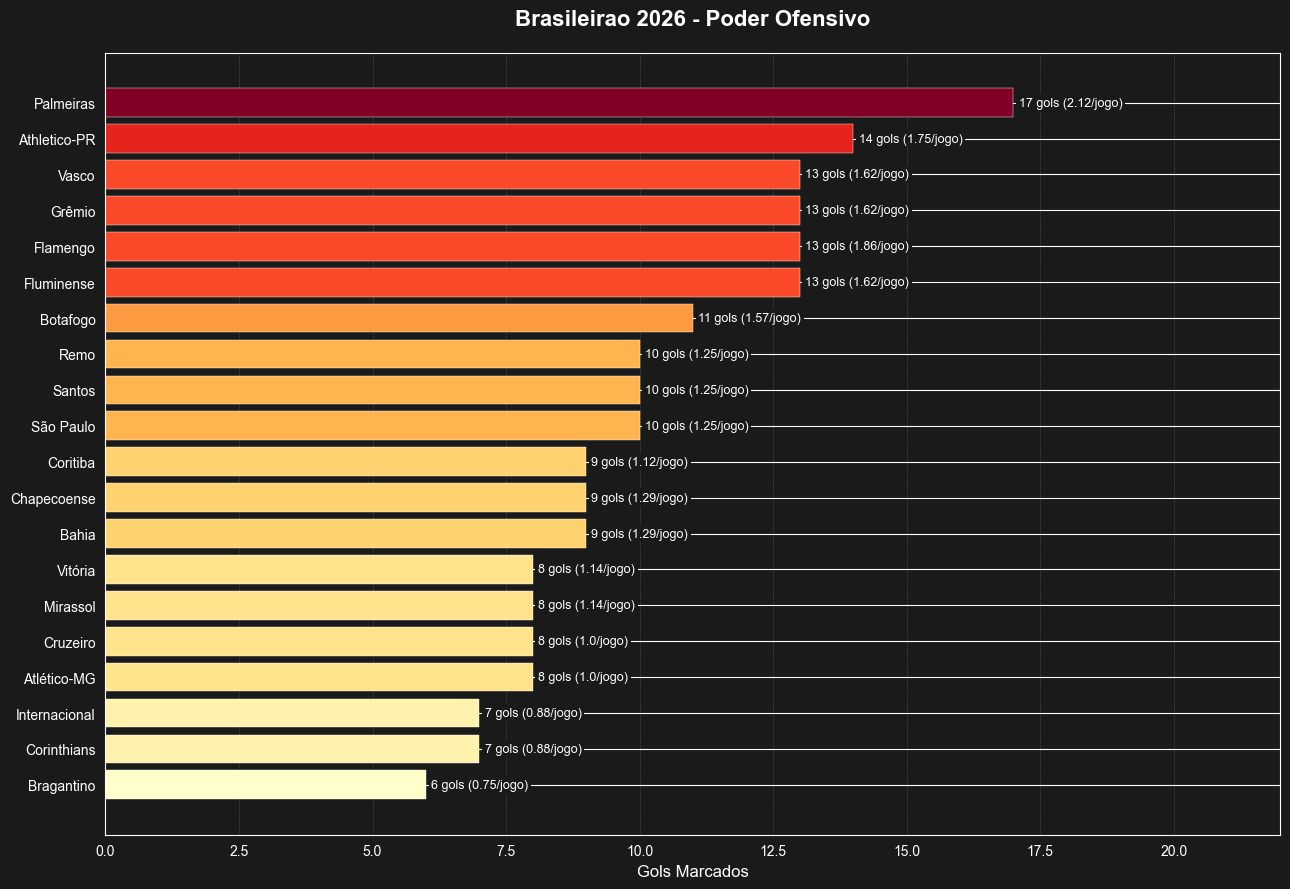

Grafico salvo


In [41]:
#Gráfico segundo bloco: Poder Ofensivo

fig, ax = plt.subplots(figsize=(14, 9))
plt.style.use('dark_background')
fig.patch.set_facecolor('#1a1a1a')
ax.set_facecolor('#1a1a1a')

plot_data = ofensivo.sort_values('gols_marcados', ascending=True)

#Cor gradiente por gols - quanto mais gols, mais forte
import matplotlib.cm as cm
import numpy as np

norm = plt.Normalize(plot_data['gols_marcados'].min(), plot_data['gols_marcados'].max())
cores = cm.YlOrRd(norm(plot_data['gols_marcados'].values))

bars = ax.barh(
    plot_data['time_popular'],
    plot_data['gols_marcados'],
    color=cores,
    edgecolor='white',
    linewidth=0.3
)

#Rótulo de dados:
for bar, gols, media in zip(bars, plot_data['gols_marcados'], plot_data['media_gols']):
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{int(gols)} gols ({media}/jogo)',
        va='center', ha='left', fontsize=9, color='white',
        bbox=dict(facecolor='#1a1a1a', edgecolor='none', pad=2)
    )

#Grade:
ax.xaxis.grid(True, color='gray', linestyle='--', linewidth=0.4, alpha=0.5)
ax.set_axisbelow(True)

#Títulos:
ax.set_title('Brasileirao 2026 - Poder Ofensivo', fontsize=16, fontweight='bold', pad=20, color='white')
ax.set_xlabel('Gols Marcados', fontsize=12, color='white')
ax.tick_params(colors='white')
ax.set_xlim(0, plot_data['gols_marcados'].max() + 5)

plt.tight_layout()
plt.subplots_adjust(left=0.15)
plt.savefig('poder_ofensivo_2026.png', dpi=150, bbox_inches='tight')
plt.show()

print("Grafico salvo")

In [42]:
ofensivo.to_csv('poder_ofensivo_2026.csv', index=False)
print("Salvo!")

Salvo!


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

df = pd.read_csv('brasileirao_2026.csv')
tabela_final = pd.read_csv('tabela_desempenho_2026.csv')

print("Dados carregados!")
print(f"Times: {len(tabela_final)}")

Dados carregados!
Times: 20


In [44]:
#Terceiro bloco: Solidez Defensiva

defensivo = tabela_final[['time_popular', 'jogos', 'gols_sofridos']].copy()
defensivo['media_sofridos'] = (defensivo['gols_sofridos'] / defensivo['jogos']).round(2)
defensivo = defensivo.sort_values('gols_sofridos', ascending=True).reset_index(drop=True)
defensivo.index += 1

print("BRASILEIRAO 2026 — Ranking Defensivo")
print(defensivo.to_string())

BRASILEIRAO 2026 — Ranking Defensivo
     time_popular  jogos  gols_sofridos  media_sofridos
1       São Paulo      8            5.0            0.62
2        Flamengo      7            5.0            0.71
3           Bahia      7            7.0            1.00
4     Corinthians      8            7.0            0.88
5        Coritiba      8            8.0            1.00
6    Athletico-PR      8            8.0            1.00
7       Palmeiras      8            8.0            1.00
8      Fluminense      8            9.0            1.12
9   Internacional      8            9.0            1.12
10        Vitória      7           10.0            1.43
11     Bragantino      8           10.0            1.25
12       Mirassol      7           10.0            1.43
13    Atlético-MG      8           11.0            1.38
14    Chapecoense      7           11.0            1.57
15         Grêmio      8           12.0            1.50
16          Vasco      8           13.0            1.62
17         

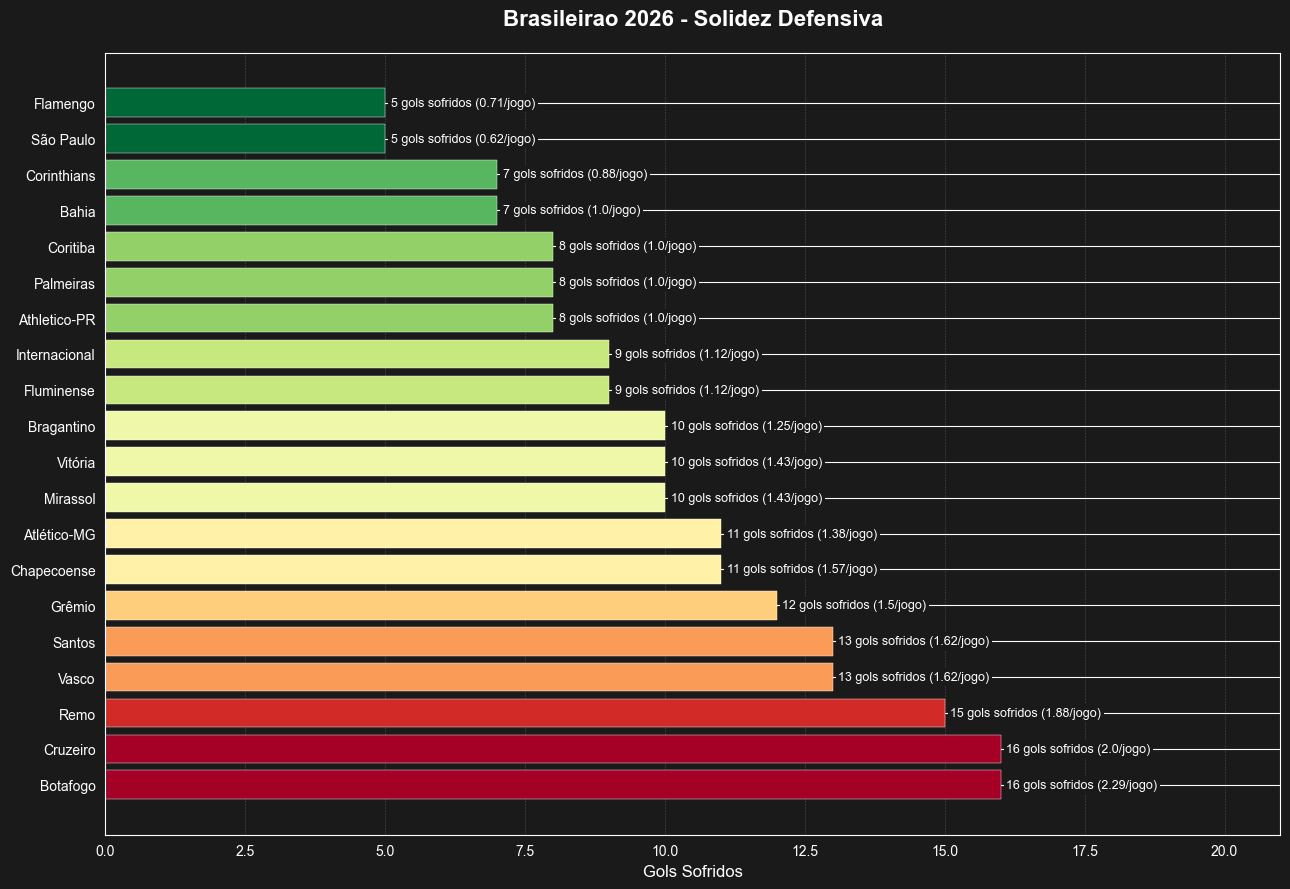

Grafico salvo


In [45]:
# Gráfico Terceiro Bloco: Solidez Defensiva
fig, ax = plt.subplots(figsize=(14, 9))
plt.style.use('dark_background')
fig.patch.set_facecolor('#1a1a1a')
ax.set_facecolor('#1a1a1a')

# Ordenando — menos gols sofridos no topo
plot_data = defensivo.sort_values('gols_sofridos', ascending=False)

# Gradiente — menos gols sofridos = mais verde
norm = plt.Normalize(plot_data['gols_sofridos'].min(), plot_data['gols_sofridos'].max())
cores = cm.RdYlGn_r(norm(plot_data['gols_sofridos'].values))

bars = ax.barh(
    plot_data['time_popular'],
    plot_data['gols_sofridos'],
    color=cores,
    edgecolor='white',
    linewidth=0.3
)

# Rótulo de Dados
for bar, gols, media in zip(bars, plot_data['gols_sofridos'], plot_data['media_sofridos']):
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{int(gols)} gols sofridos ({media}/jogo)',
        va='center', ha='left', fontsize=9, color='white',
        bbox=dict(facecolor='#1a1a1a', edgecolor='none', pad=2)
    )

# Grade
ax.xaxis.grid(True, color='gray', linestyle='--', linewidth=0.4, alpha=0.5)
ax.set_axisbelow(True)

# Títulos
ax.set_title('Brasileirao 2026 - Solidez Defensiva', fontsize=16, fontweight='bold', pad=20, color='white')
ax.set_xlabel('Gols Sofridos', fontsize=12, color='white')
ax.tick_params(colors='white')
ax.set_xlim(0, plot_data['gols_sofridos'].max() + 5)

plt.tight_layout()
plt.subplots_adjust(left=0.15)
plt.savefig('solidez_defensiva_2026.png', dpi=150, bbox_inches='tight')
plt.show()

print("Grafico salvo")

In [46]:
defensivo.to_csv('solidez_defensiva_2026.csv', index=False)
print("Salvo")

Salvo


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import numpy as np

#Carregando os dados
df = pd.read_csv('brasileirao_2026.csv')
tabela_final = pd.read_csv('tabela_desempenho_2026.csv')

print("Dados carregados")

Dados carregados


In [48]:
#Quarto bloco: Saldo de Gols

#Criando o dataframe
saldo = tabela_final[['time_popular', 'gols_marcados', 'gols_sofridos']].copy()

saldo['saldo_gols'] = saldo['gols_marcados'] - saldo['gols_sofridos']

saldo = saldo.sort_values('saldo_gols', ascending=False).reset_index(drop=True)
saldo.index += 1

print("Brasileirao 2026 - Saldo de Gols")
print('_' * 40)
print(saldo.to_string())

Brasileirao 2026 - Saldo de Gols
________________________________________
     time_popular  gols_marcados  gols_sofridos  saldo_gols
1       Palmeiras           17.0            8.0         9.0
2        Flamengo           13.0            5.0         8.0
3    Athletico-PR           14.0            8.0         6.0
4       São Paulo           10.0            5.0         5.0
5      Fluminense           13.0            9.0         4.0
6           Bahia            9.0            7.0         2.0
7        Coritiba            9.0            8.0         1.0
8          Grêmio           13.0           12.0         1.0
9           Vasco           13.0           13.0         0.0
10    Corinthians            7.0            7.0         0.0
11        Vitória            8.0           10.0        -2.0
12  Internacional            7.0            9.0        -2.0
13    Chapecoense            9.0           11.0        -2.0
14       Mirassol            8.0           10.0        -2.0
15         Santos         

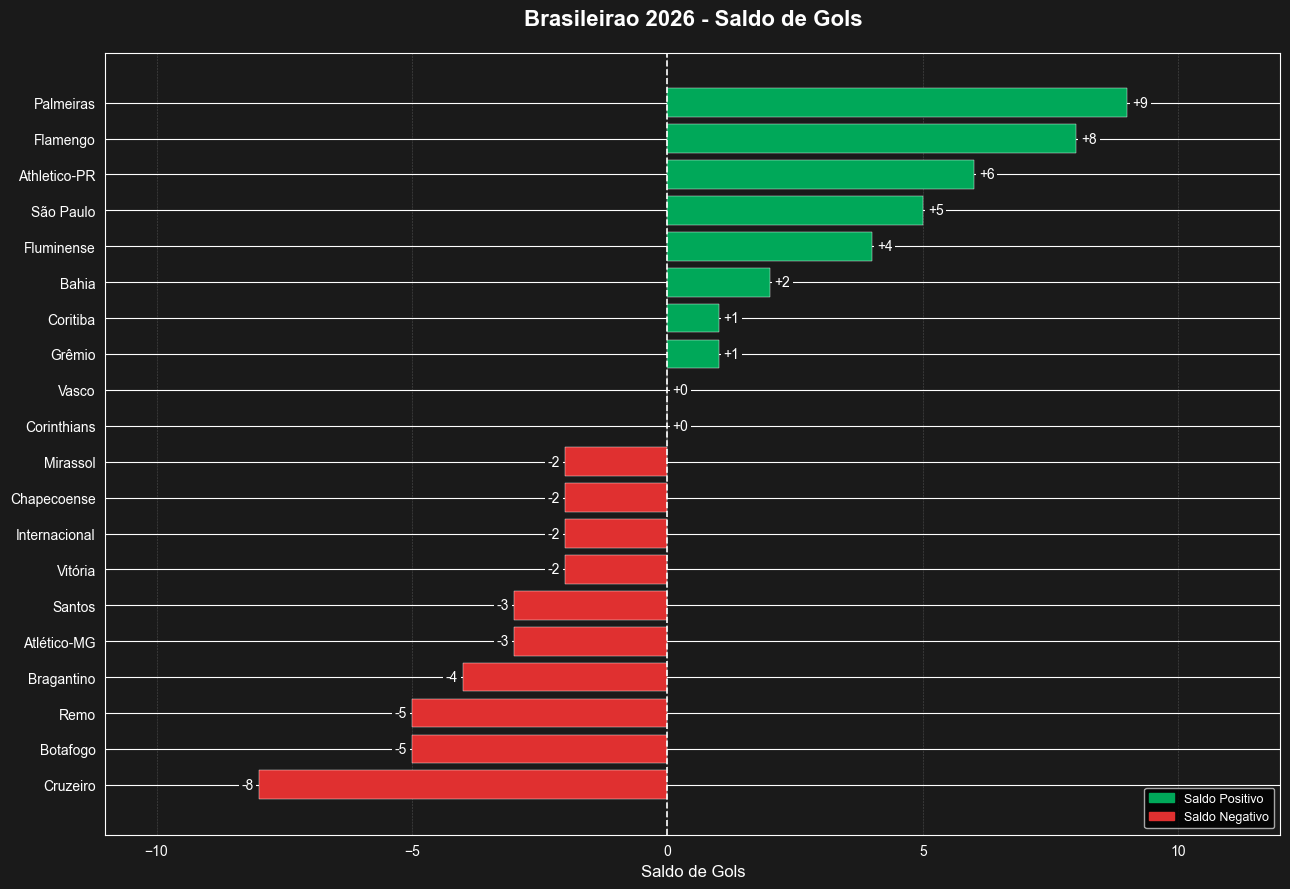

Grafico salvo


In [49]:
#Criação do Gráfio de Saldo de Gols:

plot_data = saldo.sort_values('saldo_gols', ascending=True)

cores = ['#00A859' if s >= 0 else '#E03030' for s in plot_data['saldo_gols']]

#Criação da figura:
fig, ax = plt.subplots(figsize=(14, 9))
plt.style.use('dark_background')
fig.patch.set_facecolor('#1a1a1a')
ax.set_facecolor('#1a1a1a')

#Configuração das barras:
bars = ax.barh(
    plot_data['time_popular'],
    plot_data['saldo_gols'],
    color=cores,
    edgecolor='white',
    linewidth=0.3
)

#Configuração do rótulo de dados:
for bar, saldo_val in zip(bars, plot_data['saldo_gols']):
    offset = 0.1 if saldo_val >= 0 else -0.1
    alinhamento = 'left' if saldo_val >= 0 else 'right'

    ax.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height() / 2,
        f'{int(saldo_val):+d}',
        va='center', ha=alinhamento, fontsize=10, color='white',
        bbox=dict(facecolor='#1a1a1a', edgecolor='none', pad=2)
    )

#Separação dos times positivos e negativos:
ax.axvline(x=0, color='white', linewidth=1.2, linestyle='--')

#Grade vertical:
ax.xaxis.grid(True, color='gray', linestyle='--', linewidth=0.4, alpha=0.5)
ax.set_axisbelow(True)

#Legenda de cores:
patches = [
    mpatches.Patch(color='#00A859', label='Saldo Positivo'),
    mpatches.Patch(color='#E03030', label='Saldo Negativo'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)

#Configuração do Título:
ax.set_title('Brasileirao 2026 - Saldo de Gols', fontsize=16, fontweight='bold', pad=20, color='white')
ax.set_xlabel('Saldo de Gols', fontsize=12, color='white')
ax.tick_params(colors='white')

#Ajustes de imagem:
ax.set_xlim(
    plot_data['saldo_gols'].min() - 3,
    plot_data['saldo_gols'].max() + 3
)

plt.tight_layout()
plt.subplots_adjust(left=0.15)
plt.savefig('saldo_gols_2026.png', dpi=150, bbox_inches='tight')
plt.show()

print("Grafico salvo")

In [50]:
saldo.to_csv('saldo_gols_2026.csv', index=False)
print("Salvo CSV")

Salvo CSV


In [51]:
#Quinto Bloco: Mando de Campo

#Calculo de pontos e aproveitamento:
#Em casa:
casa = df.groupby('time_casa').agg(
    jogos_casa=('time_casa', 'count'),
    vitorias_casa=('gols_casa', lambda x: (x > df.loc[x.index, 'gols_fora']).sum()),
    empates_casa=('gols_casa', lambda x: (x == df.loc[x.index, 'gols_fora']).sum()),
    derrotas_casa=('gols_casa', lambda x: (x < df.loc[x.index, 'gols_fora']).sum()),
).reset_index().rename(columns={'time_casa': 'time'})

#Fora:
fora = df.groupby('time_fora').agg(
    jogos_fora=('time_fora', 'count'),
    vitorias_fora=('gols_fora', lambda x: (x > df.loc[x.index, 'gols_casa']).sum()),
    empates_fora=('gols_fora', lambda x: (x == df.loc[x.index, 'gols_casa']).sum()),
    derrotas_fora=('gols_fora', lambda x: (x < df.loc[x.index, 'gols_casa']).sum()),
).reset_index().rename(columns={'time_fora': 'time'})

mando_base = pd.merge(casa, fora, on='time')

#Tratando nomes dos times:
nomes_populares = {
    'São Paulo FC': 'São Paulo',
    'SE Palmeiras': 'Palmeiras',
    'EC Bahia': 'Bahia',
    'Coritiba FBC': 'Coritiba',
    'Fluminense FC': 'Fluminense',
    'CR Flamengo': 'Flamengo',
    'CA Paranaense': 'Athletico-PR',
    'CA Mineiro': 'Atlético-MG',
    'SC Corinthians Paulista': 'Corinthians',
    'Grêmio FBPA': 'Grêmio',
    'RB Bragantino': 'Bragantino',
    'CR Vasco da Gama': 'Vasco',
    'EC Vitória': 'Vitória',
    'Santos FC': 'Santos',
    'Chapecoense AF': 'Chapecoense',
    'Mirassol FC': 'Mirassol',
    'SC Internacional': 'Internacional',
    'Botafogo FR': 'Botafogo',
    'Cruzeiro EC': 'Cruzeiro',
    'Clube do Remo': 'Remo',
}
mando_base['time_popular'] = mando_base['time'].map(nomes_populares).fillna(mando_base['time'])

#Calculo de aproveitamentos:
mando_base['pontos_casa'] = mando_base['vitorias_casa'] * 3 + mando_base['empates_casa']
mando_base['pontos_fora'] = mando_base['vitorias_fora'] * 3 + mando_base['empates_fora']
mando_base['aprov_casa'] = (mando_base['pontos_casa'] / (mando_base['jogos_casa'] * 3) * 100).round(1)
mando_base['aprov_fora'] = (mando_base['pontos_fora'] / (mando_base['jogos_fora'] * 3) * 100).round(1)
mando_base['aprov_total'] = mando_base['aprov_casa'] + mando_base['aprov_fora']
mando_base = mando_base.sort_values('aprov_total', ascending=False).reset_index(drop=True)
mando_base.index += 1

print("BRASILEIRAO 2026 — Mando de Campo")
print("_" * 40)
print(mando_base[['time_popular', 'aprov_casa', 'aprov_fora']].to_string())


BRASILEIRAO 2026 — Mando de Campo
________________________________________
     time_popular  aprov_casa  aprov_fora
1       Palmeiras       100.0        58.3
2        Flamengo        77.8        58.3
3      Fluminense       100.0        33.3
4       São Paulo        75.0        58.3
5           Bahia        55.6        75.0
6    Athletico-PR        80.0        44.4
7        Coritiba        33.3        66.7
8          Grêmio        83.3         8.3
9         Vitória        75.0        11.1
10    Corinthians        33.3        50.0
11          Vasco        66.7        11.1
12       Botafogo        50.0        20.0
13    Atlético-MG        66.7         0.0
14  Internacional        25.0        41.7
15     Bragantino        33.3        33.3
16    Chapecoense        50.0        11.1
17         Santos        41.7        16.7
18       Mirassol        41.7        11.1
19           Remo        41.7         8.3
20       Cruzeiro        25.0         8.3


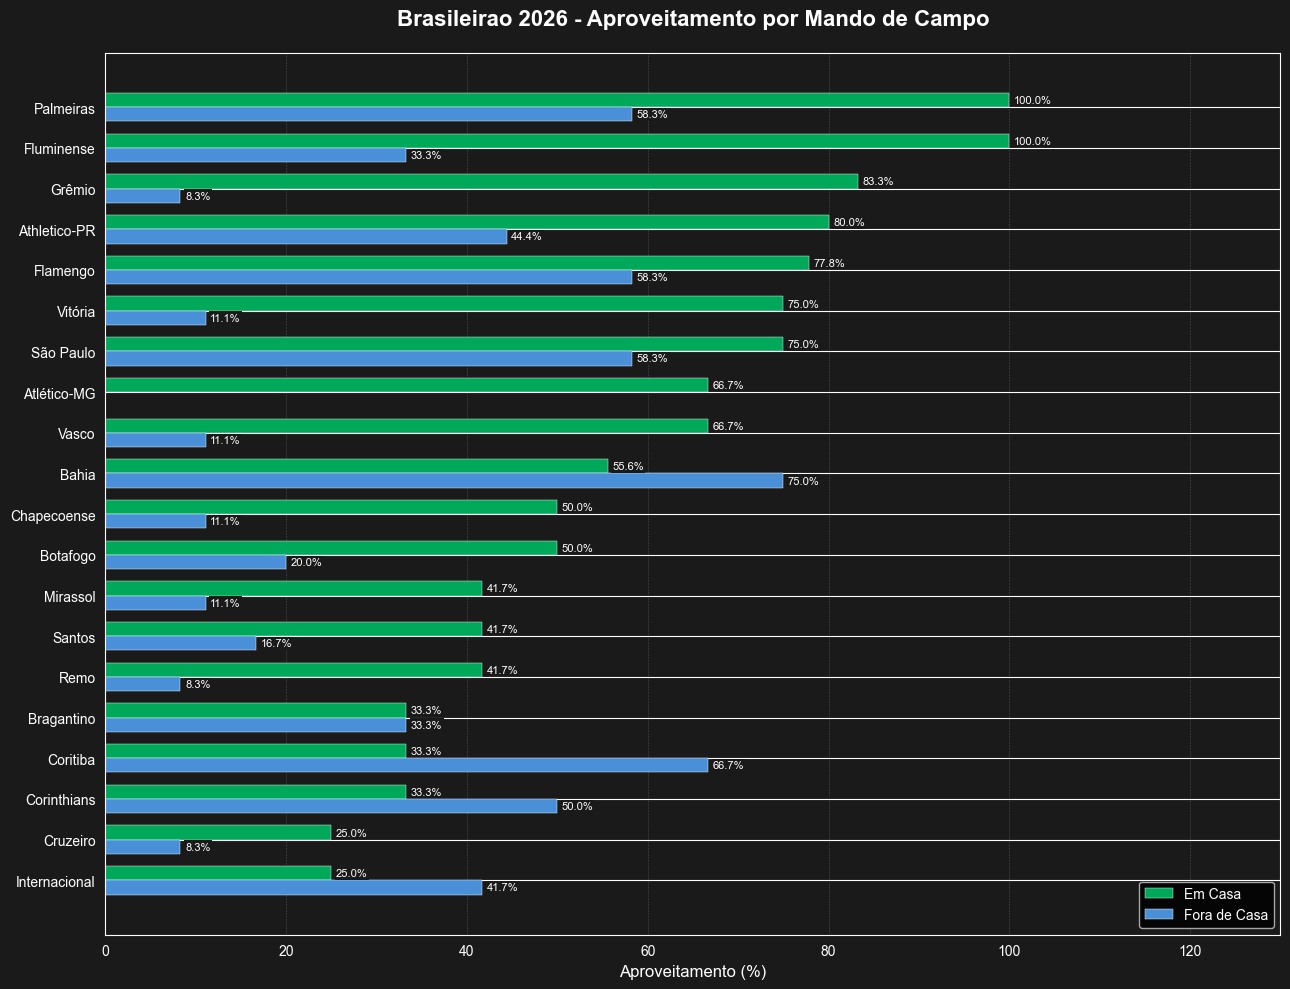

Grafico salvo


In [52]:
#Criação do gráfico do quinto bloco: Mando de Campo

fig, ax = plt.subplots(figsize=(14, 10))
plt.style.use('dark_background')
fig.patch.set_facecolor('#1a1a1a')
ax.set_facecolor('#1a1a1a')

plot_data = mando_base.sort_values('aprov_casa', ascending=True)

y = np.arange(len(plot_data))

altura = 0.35

#Barras casa:
bars_casa = ax.barh(
    y + altura / 2,         #Desloca pra cima do centro
    plot_data['aprov_casa'],
    altura,
    color='#00A859',
    edgecolor='white',
    linewidth=0.3,
    label='Em Casa'
)

#Barras fora:
bars_fora = ax.barh(
    y - altura / 2,        #Desloca pra baixo do centro
    plot_data['aprov_fora'],
    altura,
    color='#4A90D9',
    edgecolor='white',
    linewidth=0.3,
    label='Fora de Casa'
)

#Rótulo de dados nas barras de casa:
for bar, val in zip(bars_casa, plot_data['aprov_casa']):
    if val > 0:
        ax.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f'{val}%',
            va='center', ha='left', fontsize=8, color='white',
            bbox=dict(facecolor='#1a1a1a', edgecolor='none', pad=1)
        )

#Rótulo de dados nas barras de fora:
for bar, val in zip(bars_fora, plot_data['aprov_fora']):
    if val > 0:
        ax.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f'{val}%',
            va='center', ha='left', fontsize=8, color='white',
            bbox=dict(facecolor='#1a1a1a', edgecolor='none', pad=1)
        )


#Times no eixo X:
ax.set_yticks(y)
ax.set_yticklabels(plot_data['time_popular'], fontsize=10, color='white')

#Grade:
ax.xaxis.grid(True, color='gray', linestyle='--', linewidth=0.4, alpha=0.5)
ax.set_axisbelow(True)

#Legenda:
ax.legend(fontsize=10, loc='lower right')

#Títulos:
ax.set_title('Brasileirao 2026 - Aproveitamento por Mando de Campo',
             fontsize=16, fontweight='bold', pad=20, color='white')
ax.set_xlabel('Aproveitamento (%)', fontsize=12, color='white')
ax.tick_params(colors='white')
ax.set_xlim(0, 130)

plt.tight_layout()
plt.subplots_adjust(left=0.15)
plt.savefig('mando_de_campo_2026.png', dpi=150, bbox_inches='tight')
plt.show()

print("Grafico salvo")

In [53]:
mando_base.to_csv('mando_de_campo_2026.csv', index=False)
print("Salvo")

Salvo


In [54]:
#Sexto bloco: Consistência por rodada

#Calculando pontos por jogo:
def calcular_pontos(gols_time, gols_adversario):
    if gols_time > gols_adversario:
        return 3
    elif gols_time == gols_adversario:
        return 1
    else:
        return 0

registros = []

for _, jogo in df.iterrows():
    registros.append({
        'rodada': jogo['rodada'],
        'time': jogo['time_casa'],
        'pontos': calcular_pontos(jogo['gols_casa'], jogo['gols_fora'])
    })
    registros.append({
        'rodada': jogo['rodada'],
        'time': jogo['time_fora'],
        'pontos': calcular_pontos(jogo['gols_fora'], jogo['gols_casa'])
    })

df_rodadas = pd.DataFrame(registros)

df_rodadas['time'] = df_rodadas['time'].map(nomes_populares).fillna(df_rodadas['time'])

df_rodadas = df_rodadas.sort_values(['time', 'rodada'])
df_rodadas['pontos_acumulados'] = df_rodadas.groupby('time')['pontos'].cumsum()

print("BRASILEIRAO 2026 — Consistência por Rodada")
print(df_rodadas.head(20).to_string())

BRASILEIRAO 2026 — Consistência por Rodada
     rodada          time  pontos  pontos_acumulados
5         1  Athletico-PR       3                  3
58        2  Athletico-PR       0                  3
50        3  Athletico-PR       3                  6
61        4  Athletico-PR       1                  7
152       5  Athletico-PR       3                 10
97        6  Athletico-PR       0                 10
116       7  Athletico-PR       3                 13
138       8  Athletico-PR       3                 16
0         1   Atlético-MG       1                  1
21        2   Atlético-MG       0                  1
44        3   Atlético-MG       1                  2
69        4   Atlético-MG       0                  2
76        5   Atlético-MG       3                  5
93        6   Atlético-MG       0                  5
118       7   Atlético-MG       3                  8
135       8   Atlético-MG       0                  8
13        1         Bahia       3                  3
32 

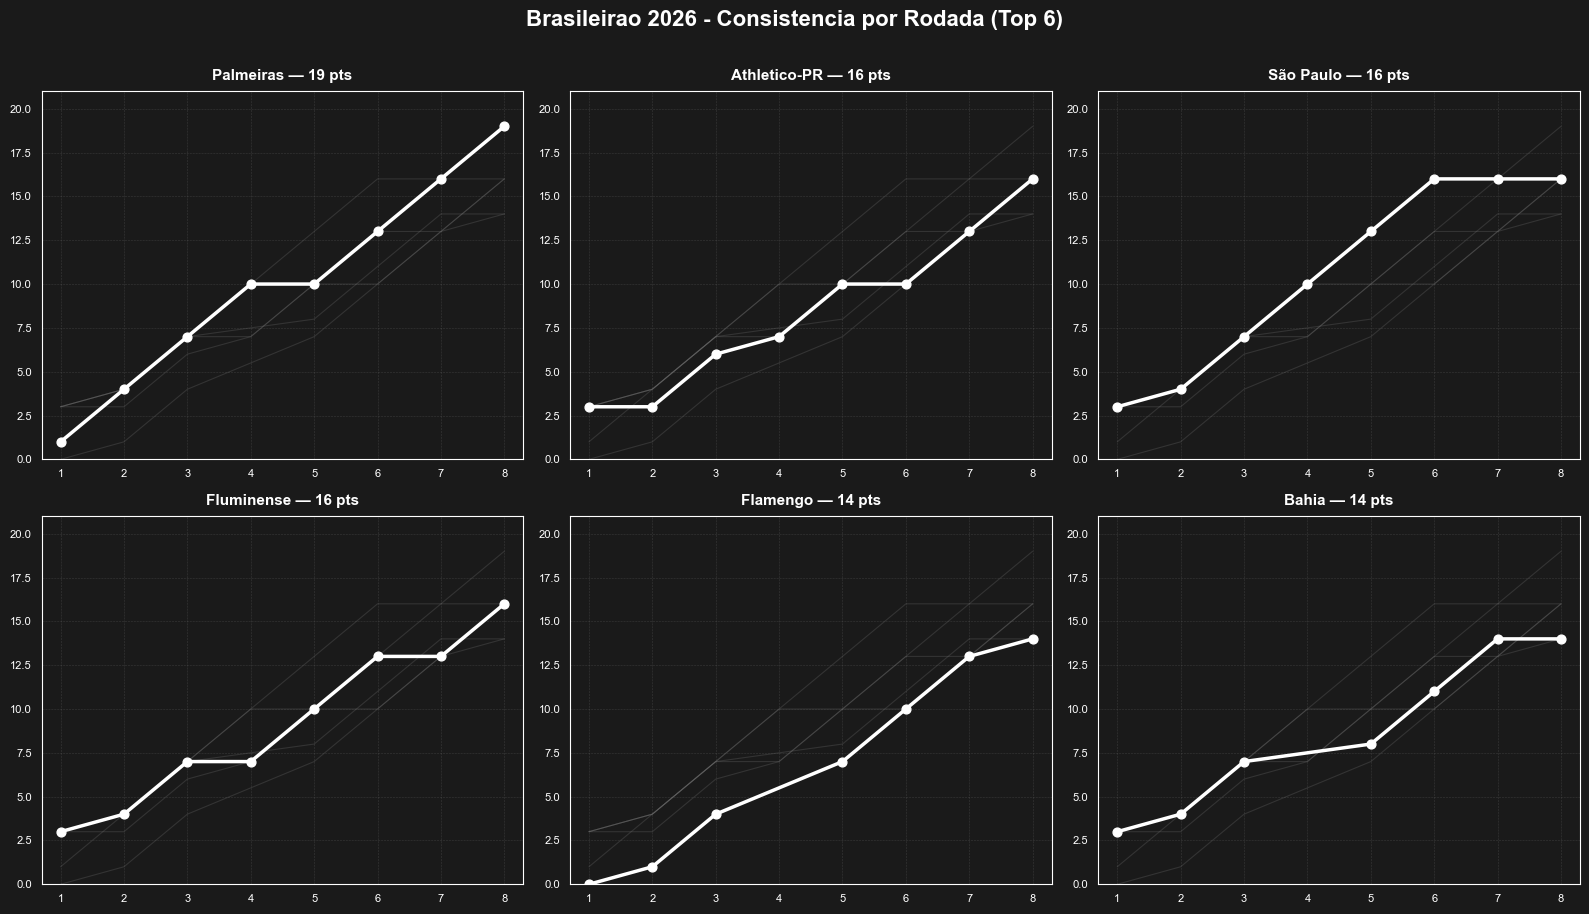

Grafico salvo!


In [55]:
# Gráfico — Bloco 6: Consistência por Rodada


# Top 6 da tabela
top6 = tabela_final['time_popular'].head(6).tolist()

# Cores individuais de cada time
cores_top6 = {
    top6[0]: '#FFFFFF',
    top6[1]: '#FFFFFF',
    top6[2]: '#FFFFFF',
    top6[3]: '#FFFFFF',
    top6[4]: '#FFFFFF',
    top6[5]: '#FFFFFF',
}

# Criando a grade 2 linhas x 3 colunas
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plt.style.use('dark_background')
fig.patch.set_facecolor('#1a1a1a')

# Achatando os eixos pra iterar facilmente
axes = axes.flatten()

# Pontos máximos pra deixar o eixo Y igual em todos os gráficos
y_max = df_rodadas['pontos_acumulados'].max() + 2
rodadas = sorted(df_rodadas['rodada'].unique())

for i, time in enumerate(top6):
    ax = axes[i]
    ax.set_facecolor('#1a1a1a')
    cor = cores_top6[time]

    # Linha cinza de fundo — todos os outros times pra referência
    for outro_time in df_rodadas['time'].unique():
        if outro_time != time and outro_time in top6:
            dados_outro = df_rodadas[df_rodadas['time'] == outro_time].sort_values('rodada')
            ax.plot(
                dados_outro['rodada'],
                dados_outro['pontos_acumulados'],
                color='gray',
                linewidth=0.8,
                alpha=0.25,
                zorder=1
            )

    # Linha principal do time
    dados_time = df_rodadas[df_rodadas['time'] == time].sort_values('rodada')
    ax.plot(
        dados_time['rodada'],
        dados_time['pontos_acumulados'],
        color=cor,
        linewidth=2.5,
        zorder=5
    )

    # Pontos em cada rodada
    ax.scatter(
        dados_time['rodada'],
        dados_time['pontos_acumulados'],
        color=cor,
        s=40,
        zorder=6
    )

    # Título de cada mini gráfico
    pontos_atual = dados_time['pontos_acumulados'].iloc[-1]
    ax.set_title(f'{time} — {int(pontos_atual)} pts',
                 fontsize=11, fontweight='bold', color=cor, pad=8)

    # Grade
    ax.xaxis.grid(True, color='gray', linestyle='--', linewidth=0.4, alpha=0.3)
    ax.yaxis.grid(True, color='gray', linestyle='--', linewidth=0.4, alpha=0.3)
    ax.set_axisbelow(True)

    # Eixos iguais em todos
    ax.set_xticks(rodadas)
    ax.set_xlim(rodadas[0] - 0.3, rodadas[-1] + 0.3)
    ax.set_ylim(0, y_max)
    ax.tick_params(colors='white', labelsize=8)

# Título geral
fig.suptitle('Brasileirao 2026 - Consistencia por Rodada (Top 6)',
             fontsize=16, fontweight='bold', color='white', y=1.01)

plt.tight_layout()
plt.savefig('consistencia_rodadas_2026.png', dpi=150, bbox_inches='tight')
plt.show()

print("Grafico salvo!")

In [56]:
# Bloco 7 — Probabilidade de Título
# Vamos projetar os pontos finais de cada time
# baseado no aproveitamento atual extrapolado pra 38 rodadas
# É uma estimativa estatística — não é previsão exata

# Total de rodadas no Brasileirão
TOTAL_RODADAS = 38
TOTAL_PONTOS_POSSIVEIS = TOTAL_RODADAS * 3  # 114 pontos máximos

# Usando a tabela final já carregada
projecao = tabela_final[['time_popular', 'jogos', 'pontos', 'aproveitamento']].copy()

# Projetando pontos totais ao final das 38 rodadas
# Lógica: se o time mantiver o aproveitamento atual até o fim
projecao['pontos_projetados'] = (
    (projecao['aproveitamento'] / 100) * TOTAL_PONTOS_POSSIVEIS
).round(1)

# Historicamente no Brasileirão, ~75-78 pontos costuma ser suficiente pra ganhar
# Vamos usar 75 como linha de corte do título
PONTOS_TITULO = 75

# Calculando probabilidade simples baseada na distância até 75 pontos
# Quanto mais perto ou acima de 75, maior a chance
projecao['distancia_titulo'] = projecao['pontos_projetados'] - PONTOS_TITULO

# Normalizando pra gerar uma probabilidade entre 0% e 100%
# Times acima da linha têm chance maior
max_dist = projecao['distancia_titulo'].max()
min_dist = projecao['distancia_titulo'].min()

projecao['probabilidade'] = (
    (projecao['distancia_titulo'] - min_dist) /
    (max_dist - min_dist) * 100
).round(1)

# Ordenando pela probabilidade
projecao = projecao.sort_values('probabilidade', ascending=False).reset_index(drop=True)
projecao.index += 1

projecao.to_csv('probabilidade_titulo_2026.csv', index=False)
print("Salvo!")

print("BRASILEIRAO 2026 — Projecao de Titulo")
print("=" * 55)
print(projecao[['time_popular', 'jogos', 'pontos', 'pontos_projetados', 'probabilidade']].to_string())

Salvo!
BRASILEIRAO 2026 — Projecao de Titulo
     time_popular  jogos  pontos  pontos_projetados  probabilidade
1       Palmeiras      8      19               90.3          100.0
2    Athletico-PR      8      16               76.0           79.9
3       São Paulo      8      16               76.0           79.9
4      Fluminense      8      16               76.0           79.9
5        Flamengo      7      14               76.0           79.9
6           Bahia      7      14               76.0           79.9
7        Coritiba      8      13               61.8           60.0
8         Vitória      7      10               54.3           49.5
9          Grêmio      8      11               52.2           46.6
10          Vasco      8      11               52.2           46.6
11    Corinthians      8      10               47.5           40.0
12  Internacional      8       8               38.0           26.6
13    Atlético-MG      8       8               38.0           26.6
14     Bragantino

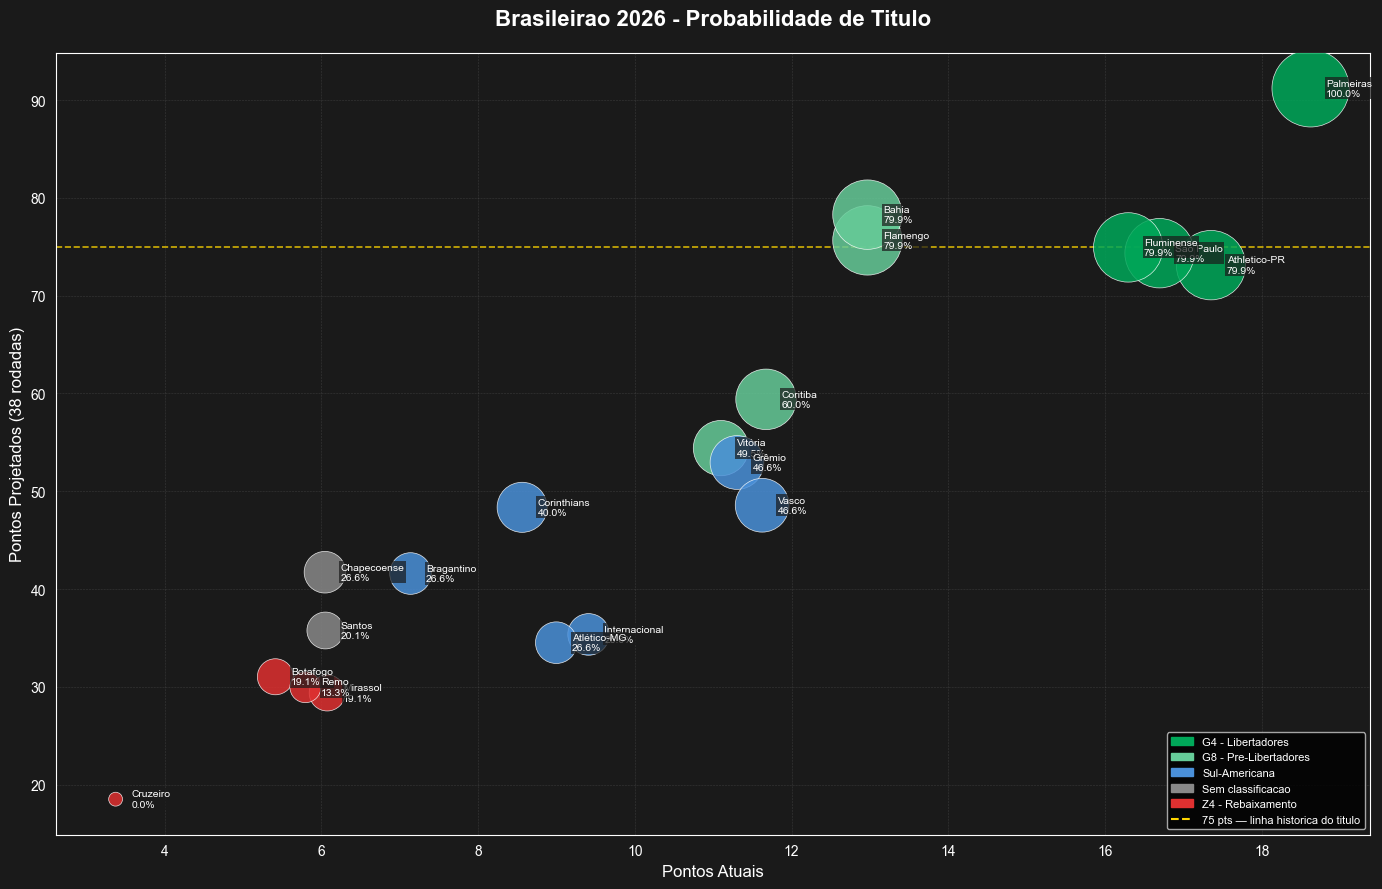

Grafico salvo!


In [57]:
# Bloco 7 — Gráfico de Bolhas: Probabilidade de Título
# Eixo X = pontos atuais
# Eixo Y = pontos projetados
# Tamanho da bolha = probabilidade
# Cor = zona de classificação

fig, ax = plt.subplots(figsize=(14, 9))
plt.style.use('dark_background')
fig.patch.set_facecolor('#1a1a1a')
ax.set_facecolor('#1a1a1a')

# Definindo cor por zona de classificação
def cor_zona(pos):
    if pos <= 4:
        return '#00A859'    # Verde — Libertadores
    elif pos <= 8:
        return '#66CC99'    # Verde claro — Pré-Libertadores
    elif pos <= 14:
        return '#4A90D9'    # Azul — Sul-Americana
    elif pos <= 16:
        return '#888888'    # Cinza — Sem classificação
    else:
        return '#E03030'    # Vermelho — Rebaixamento

cores = [cor_zona(i+1) for i in range(len(projecao))]

# Tamanho da bolha proporcional à probabilidade
# Multiplicamos por 30 pra ficar visualmente bom
tamanhos = projecao['probabilidade'] * 30 + 100  # +100 pra times com prob baixa não sumirem

# Adicionando pequeno deslocamento aleatório pra separar times sobrepostos
np.random.seed(42)  # Seed fixa pra resultado reproduzível

# Jitter — pequeno ruído nos eixos X e Y
jitter_x = np.random.uniform(-1.5, 1.5, len(projecao))
jitter_y = np.random.uniform(-4.0, 4.0, len(projecao))

# Aplicando o jitter nas posições
x_pos = projecao['pontos'] + jitter_x
y_pos = projecao['pontos_projetados'] + jitter_y

# Desenhando as bolhas
scatter = ax.scatter(
    x_pos,
    y_pos,
    s=tamanhos,
    c=cores,
    alpha=0.85,
    edgecolors='white',
    linewidth=0.5,
    zorder=5
)

x_list = list(x_pos)
y_list = list(y_pos)

# Nos labels, usa enumerate pra pegar o jitter certo
for i, (_, row) in enumerate(projecao.iterrows()):
    ax.text(
        x_list[i] + 0.2,
        y_list[i],
        f"{row['time_popular']}\n{row['probabilidade']}%",
        fontsize=7.5,
        color='white',
        va='center',
        ha='left',
        zorder=6,
        bbox=dict(facecolor='#1a1a1a', edgecolor='none', pad=1, alpha=0.7)
    )





# Linha de referência — 75 pontos projetados (histórico do título)
ax.axhline(y=75, color='#FFD700', linewidth=1.2,
           linestyle='--', alpha=0.8, label='75 pts — linha historica do titulo')

# Legenda de zonas
patches = [
    mpatches.Patch(color='#00A859', label='G4 - Libertadores'),
    mpatches.Patch(color='#66CC99', label='G8 - Pre-Libertadores'),
    mpatches.Patch(color='#4A90D9', label='Sul-Americana'),
    mpatches.Patch(color='#888888', label='Sem classificacao'),
    mpatches.Patch(color='#E03030', label='Z4 - Rebaixamento'),
]
ax.legend(handles=patches + [
    plt.Line2D([0], [0], color='#FFD700', linestyle='--', label='75 pts — linha historica do titulo')
], fontsize=8, loc='lower right')

# Grade
ax.xaxis.grid(True, color='gray', linestyle='--', linewidth=0.4, alpha=0.3)
ax.yaxis.grid(True, color='gray', linestyle='--', linewidth=0.4, alpha=0.3)
ax.set_axisbelow(True)

# Títulos e labels
ax.set_title('Brasileirao 2026 - Probabilidade de Titulo',
             fontsize=16, fontweight='bold', pad=20, color='white')
ax.set_xlabel('Pontos Atuais', fontsize=12, color='white')
ax.set_ylabel('Pontos Projetados (38 rodadas)', fontsize=12, color='white')
ax.tick_params(colors='white')

plt.tight_layout()
plt.savefig('probabilidade_titulo_2026.png', dpi=150, bbox_inches='tight')
plt.show()

print("Grafico salvo!")